
[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\FA23-BCS-041.CUI\AppData\Local\Temp\ipykernel_10028\3885578021.py:30: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')


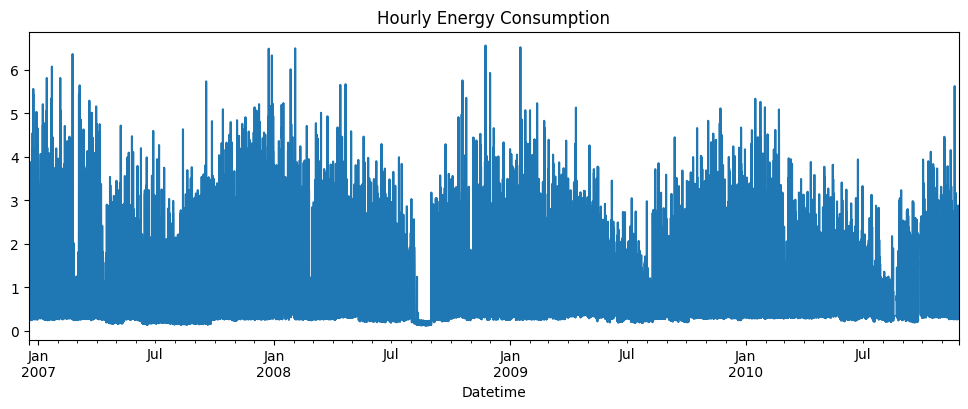

C:\Users\FA23-BCS-041.CUI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\FA23-BCS-041.CUI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\FA23-BCS-041.CUI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\FA23-BCS-041.CUI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax

ARIMA
MAE: 0.7901
RMSE: 0.9134
------------------------------
PROPHET
MAE: 0.6543
RMSE: 0.8254
------------------------------
XGBOOST
MAE: 0.3383
RMSE: 0.4859
------------------------------


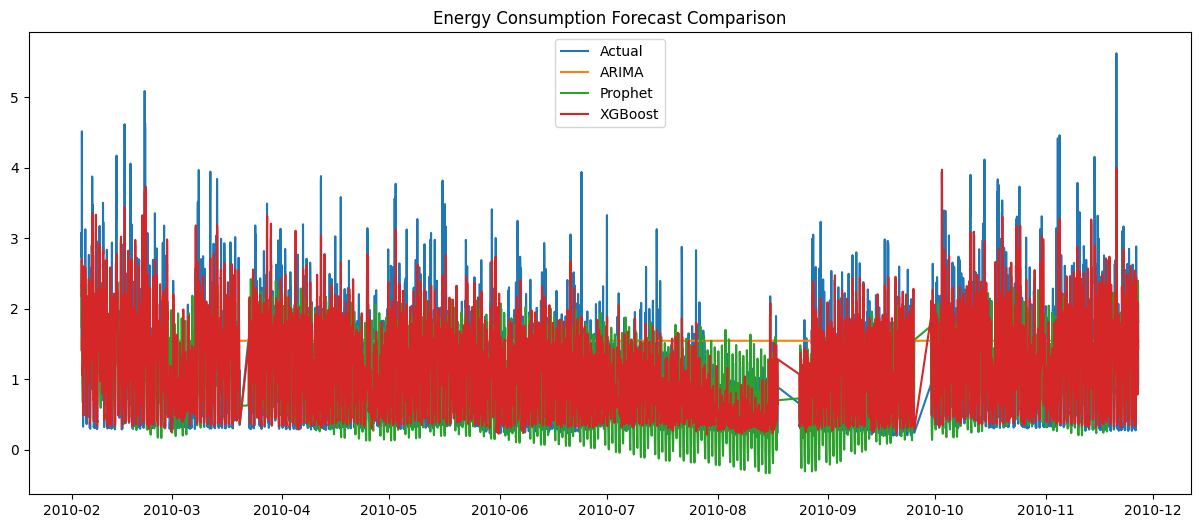

In [7]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
!pip install statsmodels
!pip install prophet
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error


# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv(
    r"C:\Users\FA23-BCS-041.CUI\Desktop\datasets\household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values=['?']
)

# Combine Date + Time
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime'])

df = df.drop(['Date', 'Time'], axis=1)
df = df.set_index('Datetime')

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()


# =========================
# 3. RESAMPLE TIME SERIES
# =========================
ts = df['Global_active_power'].resample('h').mean()

plt.figure(figsize=(12,4))
ts.plot()
plt.title("Hourly Energy Consumption")
plt.show()


# =========================
# 4. FEATURE ENGINEERING
# =========================
data = pd.DataFrame(ts)
data.columns = ['value']

data['hour'] = data.index.hour
data['day'] = data.index.day
data['weekday'] = data.index.weekday
data['month'] = data.index.month

data['lag1'] = data['value'].shift(1)
data['lag24'] = data['value'].shift(24)

data = data.dropna()


# =========================
# 5. TRAIN TEST SPLIT
# =========================
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]


# =========================
# 6. ARIMA MODEL
# =========================
arima_model = ARIMA(train['value'], order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))


# =========================
# 7. PROPHET MODEL
# =========================
prophet_df = data.reset_index()[['Datetime', 'value']]
prophet_df.columns = ['ds', 'y']

train_p = prophet_df.iloc[:train_size]

model = Prophet()
model.fit(train_p)

future = model.make_future_dataframe(periods=len(test), freq='h')
forecast = model.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test):].values


# =========================
# 8. XGBOOST MODEL
# =========================
features = ['hour', 'day', 'weekday', 'month', 'lag1', 'lag24']

X_train = train[features]
y_train = train['value']

X_test = test[features]
y_test = test['value']

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


# =========================
# 9. EVALUATION FUNCTION
# =========================
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(name)
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("-" * 30)

evaluate(test['value'], arima_pred, "ARIMA")
evaluate(test['value'], prophet_pred, "PROPHET")
evaluate(test['value'], xgb_pred, "XGBOOST")


# =========================
# 10. VISUALIZATION
# =========================
plt.figure(figsize=(15,6))

plt.plot(test.index, test['value'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.plot(test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title("Energy Consumption Forecast Comparison")
plt.show()